### 1) Importing the Libraries

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2) Loading the dataset

In [71]:
df = pd.read_csv('movies.csv')
df

,Unnamed: 0,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Directors,Genres,Country,Language,Runtime
0,0,1,Inception,2010,13+,8.8,87%,1,0,0,0,0,Christopher Nolan,"Action,Adventure,Sci-Fi,Thriller","United States,United Kingdom","English,Japanese,French",148.0
1,1,2,The Matrix,1999,18+,8.7,87%,1,0,0,0,0,"Lana Wachowski,Lilly Wachowski","Action,Sci-Fi",United States,English,136.0
2,2,3,Avengers: Infinity War,2018,13+,8.5,84%,1,0,0,0,0,"Anthony Russo,Joe Russo","Action,Adventure,Sci-Fi",United States,English,149.0
3,3,4,Back to the Future,1985,7+,8.5,96%,1,0,0,0,0,Robert Zemeckis,"Adventure,Comedy,Sci-Fi",United States,English,116.0
4,4,5,"The Good, the Bad and the Ugly",1966,18+,8.8,97%,1,0,1,0,0,Sergio Leone,Western,"Italy,Spain,West Germany",Italian,161.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16739,16739,16740,The Ghosts of Buxley Hall,1980,NaN,6.2,NaN,0,0,0,1,0,Bruce Bilson,"Comedy,Family,Fantasy,Horror",United States,English,120.0
16740,16740,16741,The Poof Point,2001,7+,4.7,NaN,0,0,0,1,0,Neal Israel,"Comedy,Family,Sci-Fi",United States,English,90.0
16741,16741,16742,Sharks of Lost Island,2013,NaN,5.7,NaN,0,0,0,1,0,Neil Gelinas,Documentary,United States,English,NaN
16742,16742,16743,Man Among Cheetahs,2017,NaN,6.6,NaN,0,0,0,1,0,Richard Slater-Jones,Documentary,United States,English,NaN


### 3) Understanding the data

In [72]:
df.columns

Index(['Unnamed: 0', 'ID', 'Title', 'Year', 'Age', 'IMDb', 'Rotten Tomatoes',
       'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Directors',
       'Genres', 'Country', 'Language', 'Runtime'],
      dtype='object')

Unnamed: 0 → Extra index column (auto-generated when saving/loading dataset). Usually not useful.

ID → Unique identifier for each movie/TV show (like a serial number).

Title → Name of the movie or TV show.

Year → Year of release.

Age → Age rating (e.g., PG, R, 13+) → tells which audience can watch.

IMDb → IMDb rating score (out of 10) given by users.

Rotten Tomatoes → Rotten Tomatoes critic rating (percentage, e.g., 85%).

Netflix → 1 = Available on Netflix, 0 = Not available.

Hulu → 1 = Available on Hulu, 0 = Not available.

Prime Video → 1 = Available on Amazon Prime Video, 0 = Not available.

Disney+ → 1 = Available on Disney+, 0 = Not available.

Type → Movie or TV Show (the content type).

Directors → Name(s) of the director(s).

Genres → Category/genre of the movie (e.g., Drama, Comedy, Action).

Country → Country where the movie/show was produced.

Language → Language(s) of the movie/show.

Runtime → Duration (usually in minutes).

In [73]:
df.head()

,Unnamed: 0,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Directors,Genres,Country,Language,Runtime
0,0,1,Inception,2010,13+,8.8,87%,1,0,0,0,0,Christopher Nolan,"Action,Adventure,Sci-Fi,Thriller","United States,United Kingdom","English,Japanese,French",148.0
1,1,2,The Matrix,1999,18+,8.7,87%,1,0,0,0,0,"Lana Wachowski,Lilly Wachowski","Action,Sci-Fi",United States,English,136.0
2,2,3,Avengers: Infinity War,2018,13+,8.5,84%,1,0,0,0,0,"Anthony Russo,Joe Russo","Action,Adventure,Sci-Fi",United States,English,149.0
3,3,4,Back to the Future,1985,7+,8.5,96%,1,0,0,0,0,Robert Zemeckis,"Adventure,Comedy,Sci-Fi",United States,English,116.0
4,4,5,"The Good, the Bad and the Ugly",1966,18+,8.8,97%,1,0,1,0,0,Sergio Leone,Western,"Italy,Spain,West Germany",Italian,161.0


In [74]:
df.dtypes

Unnamed: 0           int64
ID                   int64
Title               object
Year                 int64
Age                 object
IMDb               float64
Rotten Tomatoes     object
Netflix              int64
Hulu                 int64
Prime Video          int64
Disney+              int64
Type                 int64
Directors           object
Genres              object
Country             object
Language            object
Runtime            float64
dtype: object

### 4) Data Cleaning

In [75]:
#there is no duplicate values present
df.duplicated().any()

False

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16744 entries, 0 to 16743
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       16744 non-null  int64  
 1   ID               16744 non-null  int64  
 2   Title            16744 non-null  object 
 3   Year             16744 non-null  int64  
 4   Age              7354 non-null   object 
 5   IMDb             16173 non-null  float64
 6   Rotten Tomatoes  5158 non-null   object 
 7   Netflix          16744 non-null  int64  
 8   Hulu             16744 non-null  int64  
 9   Prime Video      16744 non-null  int64  
 10  Disney+          16744 non-null  int64  
 11  Type             16744 non-null  int64  
 12  Directors        16018 non-null  object 
 13  Genres           16469 non-null  object 
 14  Country          16309 non-null  object 
 15  Language         16130 non-null  object 
 16  Runtime          16152 non-null  float64
dtypes: float64(2

In [77]:
df=df.drop(columns=['Unnamed: 0'])
df

,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Directors,Genres,Country,Language,Runtime
0,1,Inception,2010,13+,8.8,87%,1,0,0,0,0,Christopher Nolan,"Action,Adventure,Sci-Fi,Thriller","United States,United Kingdom","English,Japanese,French",148.0
1,2,The Matrix,1999,18+,8.7,87%,1,0,0,0,0,"Lana Wachowski,Lilly Wachowski","Action,Sci-Fi",United States,English,136.0
2,3,Avengers: Infinity War,2018,13+,8.5,84%,1,0,0,0,0,"Anthony Russo,Joe Russo","Action,Adventure,Sci-Fi",United States,English,149.0
3,4,Back to the Future,1985,7+,8.5,96%,1,0,0,0,0,Robert Zemeckis,"Adventure,Comedy,Sci-Fi",United States,English,116.0
4,5,"The Good, the Bad and the Ugly",1966,18+,8.8,97%,1,0,1,0,0,Sergio Leone,Western,"Italy,Spain,West Germany",Italian,161.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16739,16740,The Ghosts of Buxley Hall,1980,NaN,6.2,NaN,0,0,0,1,0,Bruce Bilson,"Comedy,Family,Fantasy,Horror",United States,English,120.0
16740,16741,The Poof Point,2001,7+,4.7,NaN,0,0,0,1,0,Neal Israel,"Comedy,Family,Sci-Fi",United States,English,90.0
16741,16742,Sharks of Lost Island,2013,NaN,5.7,NaN,0,0,0,1,0,Neil Gelinas,Documentary,United States,English,NaN
16742,16743,Man Among Cheetahs,2017,NaN,6.6,NaN,0,0,0,1,0,Richard Slater-Jones,Documentary,United States,English,NaN


In [78]:
df['Age']=df['Age'].fillna(df['Age'].mode()[0])
df['Rotten Tomatoes']=df['Rotten Tomatoes'].fillna(df['Rotten Tomatoes'].mode()[0])
df['IMDb']=df['IMDb'].fillna(df['IMDb'].mean()).round(1)
df['Runtime']=df['Runtime'].fillna(df['Runtime'].mean()).round(1)
for i in ['Directors','Genres','Country','Language']:
    df[i]=df[i].fillna('Unknown')
df['Rotten Tomatoes']=(df['Rotten Tomatoes'].str.strip('%').astype(float)/10).round(1)
df


,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Directors,Genres,Country,Language,Runtime
0,1,Inception,2010,13+,8.8,8.7,1,0,0,0,0,Christopher Nolan,"Action,Adventure,Sci-Fi,Thriller","United States,United Kingdom","English,Japanese,French",148.0
1,2,The Matrix,1999,18+,8.7,8.7,1,0,0,0,0,"Lana Wachowski,Lilly Wachowski","Action,Sci-Fi",United States,English,136.0
2,3,Avengers: Infinity War,2018,13+,8.5,8.4,1,0,0,0,0,"Anthony Russo,Joe Russo","Action,Adventure,Sci-Fi",United States,English,149.0
3,4,Back to the Future,1985,7+,8.5,9.6,1,0,0,0,0,Robert Zemeckis,"Adventure,Comedy,Sci-Fi",United States,English,116.0
4,5,"The Good, the Bad and the Ugly",1966,18+,8.8,9.7,1,0,1,0,0,Sergio Leone,Western,"Italy,Spain,West Germany",Italian,161.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16739,16740,The Ghosts of Buxley Hall,1980,18+,6.2,10.0,0,0,0,1,0,Bruce Bilson,"Comedy,Family,Fantasy,Horror",United States,English,120.0
16740,16741,The Poof Point,2001,7+,4.7,10.0,0,0,0,1,0,Neal Israel,"Comedy,Family,Sci-Fi",United States,English,90.0
16741,16742,Sharks of Lost Island,2013,18+,5.7,10.0,0,0,0,1,0,Neil Gelinas,Documentary,United States,English,93.4
16742,16743,Man Among Cheetahs,2017,18+,6.6,10.0,0,0,0,1,0,Richard Slater-Jones,Documentary,United States,English,93.4


DATA ANALYSIS
------------------------------------------------------

1. How many unique movies are in the dataset?

In [79]:
df['Title'].count()

16744


2. What is the average IMDb rating of all movies?

In [80]:
df['IMDb'].mean()

5.902657668418538


3. How many movies were released each year?

In [81]:
df['Year'].value_counts().sort_index()

Year
1902       1
1912       1
1913       2
1915       4
1916       1
        ... 
2016    1206
2017    1401
2018    1285
2019     689
2020     147
Name: count, Length: 109, dtype: int64

4. What is the most common genre in the dataset?

In [82]:
df['Genres'].mode()

0    Drama
Name: Genres, dtype: object


5. What is the most common language for movies?

In [83]:
df['Language'].mode()

0    English
Name: Language, dtype: object

6. How many movies are available on each streaming platform?

In [84]:
platform_counts = {
    "Netflix": df["Netflix"].sum(),
    "Hulu": df["Hulu"].sum(),
    "Prime Video": df["Prime Video"].sum(),
    "Disney+": df["Disney+"].sum()
}
platform_counts
#or
# platform_counts = df[["Netflix", "Hulu", "Prime Video", "Disney+"]].sum()
# platform_counts

{'Netflix': 3560, 'Hulu': 903, 'Prime Video': 12354, 'Disney+': 564}

7. Which platform has the highest average IMDb rating?

In [85]:
avg_ratings = {
    "Netflix": df[df["Netflix"] == 1]["IMDb"].mean().round(1),
    "Hulu": df[df["Hulu"] == 1]["IMDb"].mean().round(1),
    "Prime Video": df[df["Prime Video"] == 1]["IMDb"].mean().round(1),
    "Disney+": df[df["Disney+"] == 1]["IMDb"].mean().round(1)
}

print(avg_ratings)

# Find platform with highest average IMDb
best_platform = max(avg_ratings, key=avg_ratings.get)
print("Highest average IMDb platform:", best_platform, "→", avg_ratings[best_platform])

#or we can also use functions
# platform_avg = {}

# for platform in ["Netflix", "Hulu", "Prime Video", "Disney+"]:
#     avg_rating = df.loc[df[platform] == 1, "IMDb"].mean().round(1)
#     platform_avg[platform] = avg_rating

# print(platform_avg)

# # Find which platform has the highest average IMDb rating
# best_platform = max(platform_avg, key=platform_avg.get)
# print("Platform with highest average IMDb rating:", best_platform, "→", platform_avg[best_platform])

{'Netflix': 6.2, 'Hulu': 6.1, 'Prime Video': 5.8, 'Disney+': 6.4}
Highest average IMDb platform: Disney+ → 6.4


8. Are there any movies available on all four platforms (Netflix, Hulu, Prime Video, Disney+)?


In [86]:
all_platforms = df[(df["Netflix"] == 1) & 
                   (df["Hulu"] == 1) & 
                   (df["Prime Video"] == 1) & 
                   (df["Disney+"] == 1)]

# Number of movies on all platforms
print("Number of movies available on all four platforms:", len(all_platforms))

# Optional: show titles
print("Movies available on all four platforms:")
print(all_platforms["Title"].tolist())

Number of movies available on all four platforms: 0
Movies available on all four platforms:
[]


9. Which platform has the most movies with an IMDb rating above 8.0?

In [87]:
high_imdb = df[df["IMDb"] > 8.0]

# Count movies per platform
platform_counts = {
    "Netflix": high_imdb["Netflix"].sum(),
    "Hulu": high_imdb["Hulu"].sum(),
    "Prime Video": high_imdb["Prime Video"].sum(),
    "Disney+": high_imdb["Disney+"].sum()
}

print(platform_counts)

# Platform with the most high-rated movies
best_platform = max(platform_counts, key=platform_counts.get)
print("Platform with most movies IMDb > 8.0:", best_platform, "→", platform_counts[best_platform])

{'Netflix': 129, 'Hulu': 23, 'Prime Video': 324, 'Disney+': 21}
Platform with most movies IMDb > 8.0: Prime Video → 324


10. Which platform has the most movies released after 2015?

In [88]:
after_2015 = df[df["Year"] > 2015]

# Count movies per platform
platform_counts = after_2015[["Netflix", "Hulu", "Prime Video", "Disney+"]].sum()

print(platform_counts)

# Platform with most movies after 2015
best_platform = platform_counts.idxmax()
print("Platform with most movies released after 2015:", best_platform, "→", platform_counts[best_platform])

Netflix        2105
Hulu            454
Prime Video    2321
Disney+          87
dtype: int64
Platform with most movies released after 2015: Prime Video → 2321


11. What are the top 5 genres with the most movies?

In [89]:
all_genres = df["Genres"].str.split(",")
all_genres

0        [Action, Adventure, Sci-Fi, Thriller]
1                             [Action, Sci-Fi]
2                  [Action, Adventure, Sci-Fi]
3                  [Adventure, Comedy, Sci-Fi]
4                                    [Western]
                         ...                  
16739        [Comedy, Family, Fantasy, Horror]
16740                 [Comedy, Family, Sci-Fi]
16741                            [Documentary]
16742                            [Documentary]
16743             [Documentary, Short, Family]
Name: Genres, Length: 16744, dtype: object

In [90]:
# Split genres into separate entries
all_genres = df["Genres"].str.split(",")

# Flatten into a single list
flat_genres = [genre.strip() for sublist in all_genres for genre in sublist]

# Count occurrences of each genre
genre_counts = pd.Series(flat_genres).value_counts()

# Top 5 genres
top5_genres = genre_counts.head(5)
top5_genres



Drama          7227
Comedy         4637
Thriller       3354
Action         2683
Documentary    2546
Name: count, dtype: int64

12. Which genre has the highest average IMDb rating?

In [91]:
# Step 1: Split genres into lists
df["Genres_split"] = df["Genres"].str.split(",")

# Step 2: Explode so each genre gets its own row
genre_df = df.explode("Genres_split")

# Step 3: Remove extra spaces
genre_df["Genres_split"] = genre_df["Genres_split"].str.strip()

# Step 4: Group by genre and find average IMDb
avg_ratings = genre_df.groupby("Genres_split")["IMDb"].mean()

# Step 5: Get the top genre
top_genre = avg_ratings.idxmax()
top_rating = avg_ratings.max()

print("Genre with highest average IMDb rating:", top_genre, "→", top_rating)


Genre with highest average IMDb rating: News → 7.063809523809525


13. What is the most popular genre on Netflix?

In [92]:
# Step 1: Filter only Netflix movies
netflix_movies = df[df["Netflix"] == 1]

# Step 2: Split and explode genres
netflix_movies = netflix_movies.assign(Genres_split = netflix_movies["Genres"].str.split(","))
netflix_movies = netflix_movies.explode("Genres_split")

# Step 3: Clean spaces
netflix_movies["Genres_split"] = netflix_movies["Genres_split"].str.strip()

# Step 4: Count genres
genre_counts = netflix_movies["Genres_split"].value_counts()

# Step 5: Get the top genre
top_genre = genre_counts.idxmax()
top_count = genre_counts.max()

print("Most popular genre on Netflix:", top_genre, "→", top_count, "movies")


Most popular genre on Netflix: Drama → 1501 movies


14. How many movies in the Comedy genre have an IMDb rating above 7.5?

In [93]:
# Step 1: Filter for Comedy movies
comedy_movies = df[df["Genres"].str.contains("Comedy", case=False, na=False)]

# Step 2: Filter those with IMDb > 7.5
high_rated_comedy = comedy_movies[comedy_movies["IMDb"] > 7.5]

# Step 3: Count them
count = len(high_rated_comedy)

print("Number of Comedy movies with IMDb > 7.5:", count)


Number of Comedy movies with IMDb > 7.5: 316


15. What is the average IMDb rating for Horror movies?

In [94]:
# Step 1: Filter Horror movies
horror_movies = df[df["Genres"].str.contains("Horror", case=False, na=False)]

# Step 2: Calculate average IMDb rating
avg_imdb_horror = horror_movies["IMDb"].mean()

print("Average IMDb rating for Horror movies:", round(avg_imdb_horror, 2))


Average IMDb rating for Horror movies: 4.73


16. Who are the top 5 directors with the most movies in the dataset?

In [95]:
# Step 1: Count number of movies per director
top_directors = df["Directors"].value_counts().head(5)

# Step 2: Display
print("Top 5 directors with most movies in the dataset:")
print(top_directors)


Top 5 directors with most movies in the dataset:
Directors
Unknown         726
Jay Chapman      36
Joseph Kane      30
Cheh Chang       26
Jim Wynorski     22
Name: count, dtype: int64


In [96]:
top_directors = df[df["Directors"] != "Unknown"]["Directors"].value_counts().head(5)
print(top_directors)


Directors
Jay Chapman     36
Joseph Kane     30
Cheh Chang      26
Sam Newfield    22
Jim Wynorski    22
Name: count, dtype: int64


17. Which director has the highest average IMDb rating?

In [97]:
# Step 1: Exclude unknown directors (optional)
known_directors = df[df["Directors"] != "Unknown"]

# Step 2: Group by director and calculate average IMDb
avg_ratings = known_directors.groupby("Directors")["IMDb"].mean()

# Step 3: Find director with highest average
top_director = avg_ratings.idxmax()
top_rating = avg_ratings.max()

print("Director with highest average IMDb rating:", top_director, "→", round(top_rating, 2))


Director with highest average IMDb rating: Danny Wu → 9.3


18. Which director has made the most Action movies?

In [98]:
# Step 1: Filter Action movies
action_movies = df[df["Genres"].str.contains("Action", case=False, na=False)]

# Step 2: Count movies per director
action_counts = action_movies["Directors"].value_counts()

# Step 3: Director with most Action movies
top_director = action_counts.idxmax()
top_count = action_counts.max()

print("Director with most Action movies:", top_director, "→", top_count, "movies")


Director with most Action movies: Unknown → 46 movies


In [99]:
# Step 1: Filter Action movies
action_movies = df[df["Genres"].str.contains("Action", case=False, na=False)]

# Step 2: Exclude Unknown directors
action_movies = action_movies[action_movies["Directors"] != "Unknown"]

# Step 3: Count movies per director
action_counts = action_movies["Directors"].value_counts()

# Step 4: Director with most Action movies
top_director = action_counts.idxmax()
top_count = action_counts.max()

print("Director with most Action movies (excluding Unknown):", top_director, "→", top_count, "movies")


Director with most Action movies (excluding Unknown): Cheh Chang → 26 movies


19. What is the average IMDb rating of movies directed by Christopher Nolan?

In [100]:
# Step 1: Filter movies directed by Christopher Nolan
nolan_movies = df[df["Directors"] == "Christopher Nolan"]

# Step 2: Calculate average IMDb rating
avg_imdb_nolan = nolan_movies["IMDb"].mean()

print("Average IMDb rating of Christopher Nolan movies:", round(avg_imdb_nolan, 2))


Average IMDb rating of Christopher Nolan movies: 8.3


20. How many movies by Steven Spielberg are available on Prime Video?

In [101]:
# Using df.query to filter Steven Spielberg movies on Prime Video
spielberg_prime = df.query('Directors == "Steven Spielberg" and `Prime Video` == 1')

# Count the movies
count = len(spielberg_prime)

print("Number of Steven Spielberg movies on Prime Video:", count)


Number of Steven Spielberg movies on Prime Video: 1


21. What are the top 5 most common languages in the dataset?

In [102]:
# Step 1: Split languages into lists
all_languages = df["Language"].str.split(",")

# Step 2: Flatten into a single list
flat_languages = [lang.strip() for sublist in all_languages for lang in sublist]

# Step 3: Count occurrences
language_counts = pd.Series(flat_languages).value_counts()

# Step 4: Top 5 languages
top5_languages = language_counts.head(5)
top5_languages


English    13233
Spanish      872
French       799
Hindi        731
Unknown      614
Name: count, dtype: int64

In [103]:
# Step 1: Split languages into lists
all_languages = df["Language"].str.split(",")

# Step 2: Flatten into a single list and clean spaces
flat_languages = [lang.strip() for sublist in all_languages for lang in sublist]

# Step 3: Convert to Series and remove 'Unknown'
language_counts = pd.Series(flat_languages)
language_counts = language_counts[language_counts != "Unknown"]

# Step 4: Count occurrences
language_counts = language_counts.value_counts()

# Step 5: Top 5 languages excluding 'Unknown'
top5_languages = language_counts.head(5)
top5_languages


English    13233
Spanish      872
French       799
Hindi        731
German       483
Name: count, dtype: int64

22. What is the average IMDb rating of French movies?

In [104]:
# Step 1: Filter movies with French language
french_movies = df[df["Language"].str.contains("French", case=False, na=False)]

# Step 2: Calculate average IMDb rating
avg_imdb_french = french_movies["IMDb"].mean()

print("Average IMDb rating of French movies:", round(avg_imdb_french, 2))


Average IMDb rating of French movies: 6.36


23. How many movies are from the United States?

In [105]:
# Filter movies from the United States
us_movies = df[df["Country"].str.contains("United States", case=False, na=False)]

# Count them
count = len(us_movies)
print("Number of movies from the United States:", count)


Number of movies from the United States: 10486


24. Which country has produced the most Drama movies?

In [106]:
# Step 1: Filter Drama movies
drama_movies = df[df["Genres"].str.contains("Drama", case=False, na=False)]

# Step 2: Count movies per country
country_counts = drama_movies["Country"].value_counts()

# Step 3: Country with most Drama movies
top_country = country_counts.idxmax()
top_count = country_counts.max()

print("Country with most Drama movies:", top_country, "→", top_count, "movies")


Country with most Drama movies: United States → 3350 movies


25. What is the most common language for movies on Hulu?

In [107]:
# Step 1: Filter Hulu movies
hulu_movies = df[df["Hulu"] == 1]

# Step 2: Split and flatten languages
all_languages = hulu_movies["Language"].str.split(",")
flat_languages = [lang.strip() for sublist in all_languages for lang in sublist]

# Step 3: Count languages
language_counts = pd.Series(flat_languages).value_counts()

# Step 4: Most common language
top_language = language_counts.idxmax()
top_count = language_counts.max()

print("Most common language for Hulu movies:", top_language, "→", top_count, "movies")


Most common language for Hulu movies: English → 815 movies


26. IMDb and Rotten Tomatoes Score Analysis

In [109]:
print("Average IMDb Rating:", df['IMDb'].mean())
print("Average Rotten Tomatoes Score:", df['Rotten Tomatoes'].mean())

print("Correlation:", df['IMDb'].corr(df['Rotten Tomatoes']))


Average IMDb Rating: 5.902657668418538
Average Rotten Tomatoes Score: 8.935021500238891
Correlation: 0.0011052694728285305


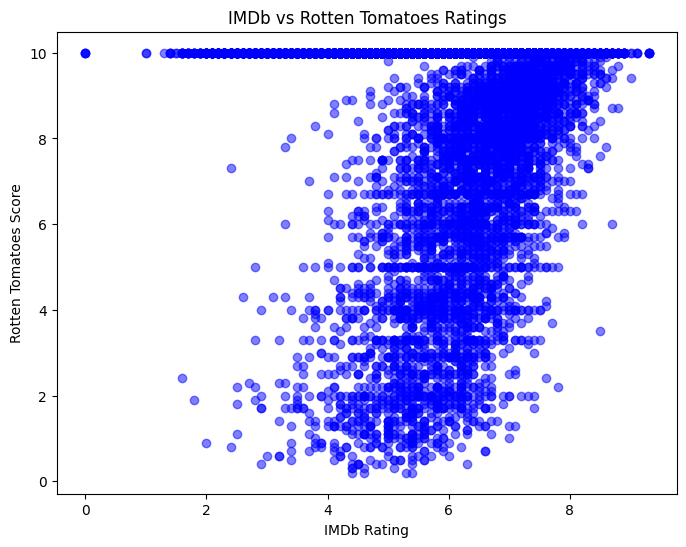

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['IMDb'], df['Rotten Tomatoes'], alpha=0.5, color="blue")
plt.title("IMDb vs Rotten Tomatoes Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Rotten Tomatoes Score")
plt.show()


27. What is the highest IMDb rating in the dataset, and which movie has it?

28. What is the lowest Rotten Tomatoes score, and which movie has it?

29. What is the correlation between IMDb ratings and Rotten Tomatoes scores?

30. How many movies have both IMDb rating above 8.0 and Rotten Tomatoes score above 90%?


31. Which platform has the highest average Rotten Tomatoes score?

32. What is the average runtime of all movies?

33. Which movie has the longest runtime?

34. Which genre tends to have the longest runtime on average?


35. How many movies have a runtime of less than 60 minutes?

36. What is the average IMDb rating for movies with a runtime above 150 minutes?